# GUS04G — Visualization of Estimated Cross Tables

**Purpose:** Load the enriched database (`geoteryt_E.pkl`) produced by
GUS04F, randomly draw one administrative unit at each level (gmina,
powiat, old voivodeship, new voivodeship), and produce time-series
plots for every E\_ cross-table subject on each drawn unit.

**Observed vs. Estimated markers:**
- *Observed* (●, filled) — the source M\_ anchor subject has real
  (non-NaN) census data for that territory × year.
- *Estimated* (○, hollow) — value was produced by the estimation
  pipeline (interpolation / IPF / Gurobi QP).
- For powiats and voivodeships all cross-table values come from
  aggregation, so they are always shown as *Estimated*.

**Old voivodeship aggregation:** Pre-1999 voivodeships are not stored
as TERYTRecords in the hierarchy.  We aggregate E\_ tables from all
gminas that share the same `old_woj` attribute.

---

In [1]:
# ── Cell 1: Imports & database load ────────────────────────────────────
import os, sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
TOOLS_PATH = os.path.join(REPO, 'Code', 'tools')
if TOOLS_PATH not in sys.path:
    sys.path.insert(0, TOOLS_PATH)

from geoTERYT_db import (
    load_complete_database,
    LEVEL_GMINA, LEVEL_POWIAT, LEVEL_VOIVODESHIP,
    RODZ_AGGREGATION_SET,
)

DATA_ROOT = os.path.join(REPO, '..', '..', 'Data', 'Geospatial')
DB_PATH = os.path.join(DATA_ROOT, 'geoteryt_E.pkl')
assert os.path.isfile(DB_PATH), f'Database not found: {DB_PATH}'

db = load_complete_database(DB_PATH)
print(f'Loaded database with {len(db._records)} records.')

Loading complete database from /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper/../../Data/Geospatial/geoteryt_E.pkl...
  Database version: 4.3
  ✓ Restored old voivodships: 49 rows
  ✓ Restored geometry store: 13,287 unique geometries
  ✓ Restored geometry data for years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  ✓ Loaded 4612 records
  ✓ Year range: 1999 - 2024
  ✓ Records with geometry: 3661
  ✓ Records with old_woj: 4104
  ✓ Records with data: 4584
  ✓ Records with cross tables: 4584
  ✓ Records with population data: 4582
  ✓ Records with pop_class: 3411
Loaded database with 4612 records.


In [33]:
# ── Cell 2: Configuration — E_ subjects and their M_ anchor mapping ───
#
# E_SUBJECT_ID  →  list of source M_ subject IDs that contain
#                   *observed* census data at gmina level.
#
# If ANY anchor subject has non-NaN data at (teryt_id, year),
# we mark that point as "observed".

E_TO_ANCHOR = {
    'E_age_sex_2000':  ['M_age_sex'],
    'E_age_sex_1990':  ['M_age_sex', 'M_age_1990'],
    'E_educ_2000':     ['M_educ_2000'],
    'E_educ_1990':     ['M_educ_1990'],
    'E_educ_sex_2000': ['M_educ_sex_2000'],
    'E_educ_sex_1990': ['M_educ_sex_1990'],
    'E_hh_size_2000':  ['M_hh_size_2000'],
    'E_hh_size_1990':  ['M_hh_size_1990'],
}

# Year ranges for each section
SECTION_YEARS = {
    '2000': list(range(1999, 2026)),  # 1999–2025
    '1990': list(range(1986, 2003)),  # 1986–2002
}

def get_section(e_sid: str) -> str:
    """Return '2000' or '1990' from the E_ subject ID."""
    return '2000' if '2000' in e_sid else '1990'

# Readable labels (for plot titles)
E_LABELS = {
    'E_age_sex_2000':  'Age × Sex (1999–2025)',
    'E_age_sex_1990':  'Age × Sex (1986–2002)',
    'E_educ_2000':     'Education (1999–2025)',
    'E_educ_1990':     'Education (1986–2002)',
    'E_educ_sex_2000': 'Education × Sex (1999–2025)',
    'E_educ_sex_1990': 'Education × Sex (1986–2002)',
    'E_hh_size_2000':  'Household Size (1999–2025)',
    'E_hh_size_1990':  'Household Size (1986–2002)',
}

# Random seed for reproducibility within a session
SEED = 476
random.seed(SEED)
np.random.seed(SEED)

print('Configuration ready.  E_ subjects:', list(E_TO_ANCHOR.keys()))

Configuration ready.  E_ subjects: ['E_age_sex_2000', 'E_age_sex_1990', 'E_educ_2000', 'E_educ_1990', 'E_educ_sex_2000', 'E_educ_sex_1990', 'E_hh_size_2000', 'E_hh_size_1990']


In [34]:
# ── Cell 3: Helper — determine observed/estimated status ──────────────

def is_year_observed(record, e_sid: str, year: int) -> bool:
    """Return True if *any* anchor M_ subject has non-NaN data at `year`
    on this record.  Only meaningful at gmina level; higher levels are
    always aggregated → False."""
    anchors = E_TO_ANCHOR.get(e_sid, [])
    for m_sid in anchors:
        ct = record.cross_tables.get(m_sid)
        if ct is None:
            continue
        tbl = ct.tables.get(year)
        if tbl is not None and not np.all(np.isnan(tbl)):
            return True
    return False


def build_time_series(record, e_sid: str):
    """Extract the per-year time series from an E_ CrossTable.

    Returns
    -------
    years : list[int]
    totals : np.ndarray, shape (n_years,)
        Sum of all cells (= total population in that table).
    observed_mask : np.ndarray[bool], shape (n_years,)
        True where the *corresponding anchor* has real data.
    """
    ct = record.cross_tables.get(e_sid)
    if ct is None:
        return [], np.array([]), np.array([], dtype=bool)
    years = sorted(ct.years_with_data)
    if not years:
        return [], np.array([]), np.array([], dtype=bool)
    totals = np.array([np.nansum(ct.tables[y]) for y in years])
    obs = np.array([is_year_observed(record, e_sid, y) for y in years])
    return years, totals, obs


def build_category_series(record, e_sid: str, dim_idx: int = 0):
    """Extract per-category time series along `dim_idx`.

    For a 2-D cross table (e.g. age × sex), summing over *all other*
    dimensions gives the marginal along `dim_idx`.

    Returns
    -------
    years : list[int]
    labels : list[str]  – category labels along the chosen dimension
    values : np.ndarray, shape (n_labels, n_years)
    observed_mask : np.ndarray[bool], shape (n_years,)
    """
    ct = record.cross_tables.get(e_sid)
    if ct is None:
        return [], [], np.empty((0, 0)), np.array([], dtype=bool)
    years = sorted(ct.years_with_data)
    if not years:
        return [], [], np.empty((0, 0)), np.array([], dtype=bool)

    dim_name = ct.dim_names[dim_idx]
    labels = ct.dim_labels[dim_name]
    n_labels = len(labels)

    # Axes to sum over: everything except dim_idx
    sum_axes = tuple(i for i in range(ct.ndim) if i != dim_idx)

    values = np.full((n_labels, len(years)), np.nan)
    for j, y in enumerate(years):
        tbl = ct.tables[y]
        if sum_axes:
            marginal = np.nansum(tbl, axis=sum_axes)
        else:
            marginal = tbl  # already 1-D
        values[:, j] = marginal

    obs = np.array([is_year_observed(record, e_sid, y) for y in years])
    return years, labels, values, obs

print('Helpers defined.')

Helpers defined.


In [35]:
# ── Cell 4: Random territory sampling ─────────────────────────────────
#
# 1. gmina   – level=6, rodz ∈ {1,2,3}, has at least one E_ subject
# 2. powiat  – level=5, has at least one E_ subject
# 3. new voivodeship – level=2, has at least one E_ subject
# 4. old voivodeship – unique old_woj name; we aggregate on the fly

e_sids = list(E_TO_ANCHOR.keys())

def has_any_e_subject(record):
    return any(sid in record.cross_tables for sid in e_sids)

# ── Gmina ──
gmina_candidates = [
    r for r in db._records.values()
    if r.level == LEVEL_GMINA
    and r.rodz in RODZ_AGGREGATION_SET
    and has_any_e_subject(r)
]
assert gmina_candidates, 'No eligible gminas found with E_ subjects!'
sampled_gmina = random.choice(gmina_candidates)

# ── Powiat ──
powiat_candidates = [
    r for r in db._records.values()
    if r.level == LEVEL_POWIAT
    and has_any_e_subject(r)
]
assert powiat_candidates, 'No eligible powiats found with E_ subjects!'
sampled_powiat = random.choice(powiat_candidates)

# ── New voivodeship ──
voiv_candidates = [
    r for r in db._records.values()
    if r.level == LEVEL_VOIVODESHIP
    and has_any_e_subject(r)
]
assert voiv_candidates, 'No eligible voivodeships found with E_ subjects!'
sampled_voiv = random.choice(voiv_candidates)

# ── Old voivodeship ──
# Collect distinct old_woj names from gminas with E_ data
old_woj_names = sorted({
    r.old_woj for r in db._records.values()
    if r.level == LEVEL_GMINA
    and r.rodz in RODZ_AGGREGATION_SET
    and r.old_woj is not None
    and has_any_e_subject(r)
})
assert old_woj_names, 'No old voivodeships found!'
sampled_old_woj = random.choice(old_woj_names)

print(f'Sampled gmina:            {sampled_gmina.name} ({sampled_gmina.teryt_id})')
print(f'Sampled powiat:           {sampled_powiat.name} ({sampled_powiat.teryt_id})')
print(f'Sampled new voivodeship:  {sampled_voiv.name} ({sampled_voiv.teryt_id})')
print(f'Sampled old voivodeship:  {sampled_old_woj}')

Sampled gmina:            Płośnica (2803052)
Sampled powiat:           Leszno (3063000)
Sampled new voivodeship:  PODKARPACKIE (1800000)
Sampled old voivodeship:  olsztyńskie


In [36]:
# ── Cell 5: Aggregate E_ tables for the old voivodeship ───────────────
#
# Build a synthetic "record-like" object that holds aggregated
# cross tables for all gminas sharing `old_woj == sampled_old_woj`.

from types import SimpleNamespace
from geoTERYT_db import CrossTable

def aggregate_old_voivodeship(db, old_woj_name: str, e_sids: list):
    """Sum E_ cross tables across all gminas with a given old_woj.

    Returns a SimpleNamespace with:
      .name          – voivodeship name
      .teryt_id      – 'old_<name>'
      .cross_tables  – {e_sid: CrossTable}
    """
    gminas = [
        r for r in db._records.values()
        if r.level == LEVEL_GMINA
        and r.rodz in RODZ_AGGREGATION_SET
        and r.old_woj == old_woj_name
    ]
    agg = SimpleNamespace(
        name=old_woj_name,
        teryt_id=f'old_{old_woj_name}',
        level=None,  # synthetic
        cross_tables={},
    )
    for e_sid in e_sids:
        running_total = None
        for g in gminas:
            ct = g.cross_tables.get(e_sid)
            if ct is None:
                continue
            if running_total is None:
                running_total = CrossTable(
                    subject_id=ct.subject_id,
                    dim_names=ct.dim_names,
                    dim_labels=ct.dim_labels,
                    subject_name=ct.subject_name,
                    year_range=ct.year_range,
                )
                # Copy tables from first gmina
                for year in ct.year_range:
                    tbl = ct.tables.get(year)
                    if tbl is not None:
                        running_total.tables[year] = tbl.copy()
            else:
                # Add element-wise (NaN-safe: NaN + NaN → NaN,
                #                             NaN + x   → x)
                for year in ct.year_range:
                    a = running_total.tables.get(year)
                    b = ct.tables.get(year)
                    if a is None or b is None:
                        continue
                    both_nan = np.isnan(a) & np.isnan(b)
                    summed = np.where(np.isnan(a), 0, a) + np.where(np.isnan(b), 0, b)
                    summed[both_nan] = np.nan
                    running_total.tables[year] = summed
        if running_total is not None:
            agg.cross_tables[e_sid] = running_total

    print(f'  Aggregated {len(gminas)} gminas for old voivodeship "{old_woj_name}"')
    print(f'  E_ subjects available: {list(agg.cross_tables.keys())}')
    return agg

sampled_old_voiv_record = aggregate_old_voivodeship(db, sampled_old_woj, e_sids)

  Aggregated 59 gminas for old voivodeship "olsztyńskie"
  E_ subjects available: ['E_age_sex_2000', 'E_age_sex_1990', 'E_educ_2000', 'E_educ_1990', 'E_educ_sex_2000', 'E_educ_sex_1990', 'E_hh_size_2000', 'E_hh_size_1990']


## Plotting Utilities

In [37]:
# ── Cell 6: Core plotting function ────────────────────────────────────

# Colour palette — up to ~20 distinguishable colours
PALETTE = (
    plt.cm.tab20.colors[:20]
)

def plot_subject_for_record(
    record,
    e_sid: str,
    ax: plt.Axes,
    *,
    dim_idx: int = 0,
    skip_total_label: str | None = 'ogółem',
    is_gmina: bool = False,
):
    """Plot one E_ subject's marginal categories on a single Axes.

    Parameters
    ----------
    record : TERYTRecord or SimpleNamespace
        Must have `.cross_tables` dict.
    e_sid : str
        E_ subject identifier.
    ax : matplotlib Axes
    dim_idx : int
        Which dimension to disaggregate.  0 = first (e.g. age groups).
    skip_total_label : str or None
        Label to skip in the per-category plot (e.g. 'ogółem' = total)
        to avoid cluttering the figure with a line that dwarfs others.
        Set to None to include all.
    is_gmina : bool
        If True, observed/estimated markers are shown per year.
        If False, all points are shown as estimated/aggregated.
    """
    years, labels, values, obs_mask = build_category_series(
        record, e_sid, dim_idx=dim_idx
    )
    if len(years) == 0:
        ax.set_title(f'{E_LABELS.get(e_sid, e_sid)}\n(no data)', fontsize=9)
        ax.set_visible(False)
        return

    years_arr = np.array(years)

    # Choose which labels to plot
    plot_idx = []
    for i, lbl in enumerate(labels):
        if skip_total_label and lbl.lower() == skip_total_label.lower():
            continue
        plot_idx.append(i)

    # If skipping the total removed everything, plot all
    if not plot_idx:
        plot_idx = list(range(len(labels)))

    for k, idx in enumerate(plot_idx):
        colour = PALETTE[k % len(PALETTE)]
        lbl = labels[idx]
        ys = values[idx, :]

        # Draw the connecting line
        ax.plot(years_arr, ys, color=colour, linewidth=0.9, alpha=0.8)

        if is_gmina:
            # Observed points: filled circle
            if obs_mask.any():
                ax.scatter(
                    years_arr[obs_mask], ys[obs_mask],
                    marker='o', s=22, color=colour, zorder=3,
                    label=f'{lbl} (obs)' if k == 0 or len(plot_idx) <= 6 else None,
                )
            # Estimated points: hollow circle
            est_mask = ~obs_mask
            if est_mask.any():
                ax.scatter(
                    years_arr[est_mask], ys[est_mask],
                    marker='o', s=22, facecolors='none',
                    edgecolors=colour, linewidths=0.8, zorder=3,
                    label=f'{lbl} (est)' if k == 0 or len(plot_idx) <= 6 else None,
                )
        else:
            # All aggregated → hollow diamonds
            ax.scatter(
                years_arr, ys,
                marker='D', s=16, facecolors='none',
                edgecolors=colour, linewidths=0.7, zorder=3,
            )

    ax.set_title(E_LABELS.get(e_sid, e_sid), fontsize=9)
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1000:.0f}k' if abs(x) >= 1000 else f'{x:.0f}'
    ))

    # Compact legend only when few categories
    if len(plot_idx) <= 6:
        # Build label handles manually for clean legend
        handles = []
        for k, idx in enumerate(plot_idx):
            colour = PALETTE[k % len(PALETTE)]
            handles.append(plt.Line2D(
                [0], [0], color=colour, linewidth=1.2,
                marker='o', markersize=4, label=labels[idx],
            ))
        ax.legend(handles=handles, fontsize=5, loc='best',
                  framealpha=0.7, ncol=1)


def plot_total_for_record(
    record,
    e_sid: str,
    ax: plt.Axes,
    *,
    is_gmina: bool = False,
):
    """Plot total population from the E_ cross table (summed across all cells)."""
    years, totals, obs_mask = build_time_series(record, e_sid)
    if len(years) == 0:
        ax.set_visible(False)
        return

    years_arr = np.array(years)
    ax.plot(years_arr, totals, color='black', linewidth=1.2)

    if is_gmina:
        if obs_mask.any():
            ax.scatter(years_arr[obs_mask], totals[obs_mask],
                       marker='o', s=30, color='steelblue',
                       label='Observed', zorder=3)
        est = ~obs_mask
        if est.any():
            ax.scatter(years_arr[est], totals[est],
                       marker='o', s=30, facecolors='none',
                       edgecolors='steelblue', linewidths=1,
                       label='Estimated', zorder=3)
        ax.legend(fontsize=7, loc='best')
    else:
        ax.scatter(years_arr, totals,
                   marker='D', s=20, facecolors='none',
                   edgecolors='black', linewidths=0.8, zorder=3)

    ax.set_title(f'{E_LABELS.get(e_sid, e_sid)} — Total', fontsize=9)
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Total count', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=8))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1000:.0f}k' if abs(x) >= 1000 else f'{x:.0f}'
    ))

print('Plotting utilities defined.')

Plotting utilities defined.


In [38]:
# ── Cell 7: Master plotting function for one territory ─────────────────

def plot_all_subjects(
    record,
    territory_label: str,
    is_gmina: bool = False,
):
    """Create a figure with sub-plots for every E_ subject on `record`.

    Layout: two columns —
      left : marginal categories (category lines)
      right: total population (single line)

    Only subjects that actually exist on the record are plotted.
    """
    present_sids = [sid for sid in e_sids if sid in record.cross_tables]
    if not present_sids:
        print(f'  ⚠ No E_ subjects found on {territory_label}')
        return

    n = len(present_sids)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.2 * n), squeeze=False)
    fig.suptitle(
        f'{territory_label}',
        fontsize=12, fontweight='bold', y=1.0,
    )

    for i, sid in enumerate(present_sids):
        plot_subject_for_record(
            record, sid, axes[i, 0],
            dim_idx=0, is_gmina=is_gmina,
        )
        plot_total_for_record(
            record, sid, axes[i, 1],
            is_gmina=is_gmina,
        )

    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

print('Master plot function defined.')

Master plot function defined.


## 1.  Random Gmina

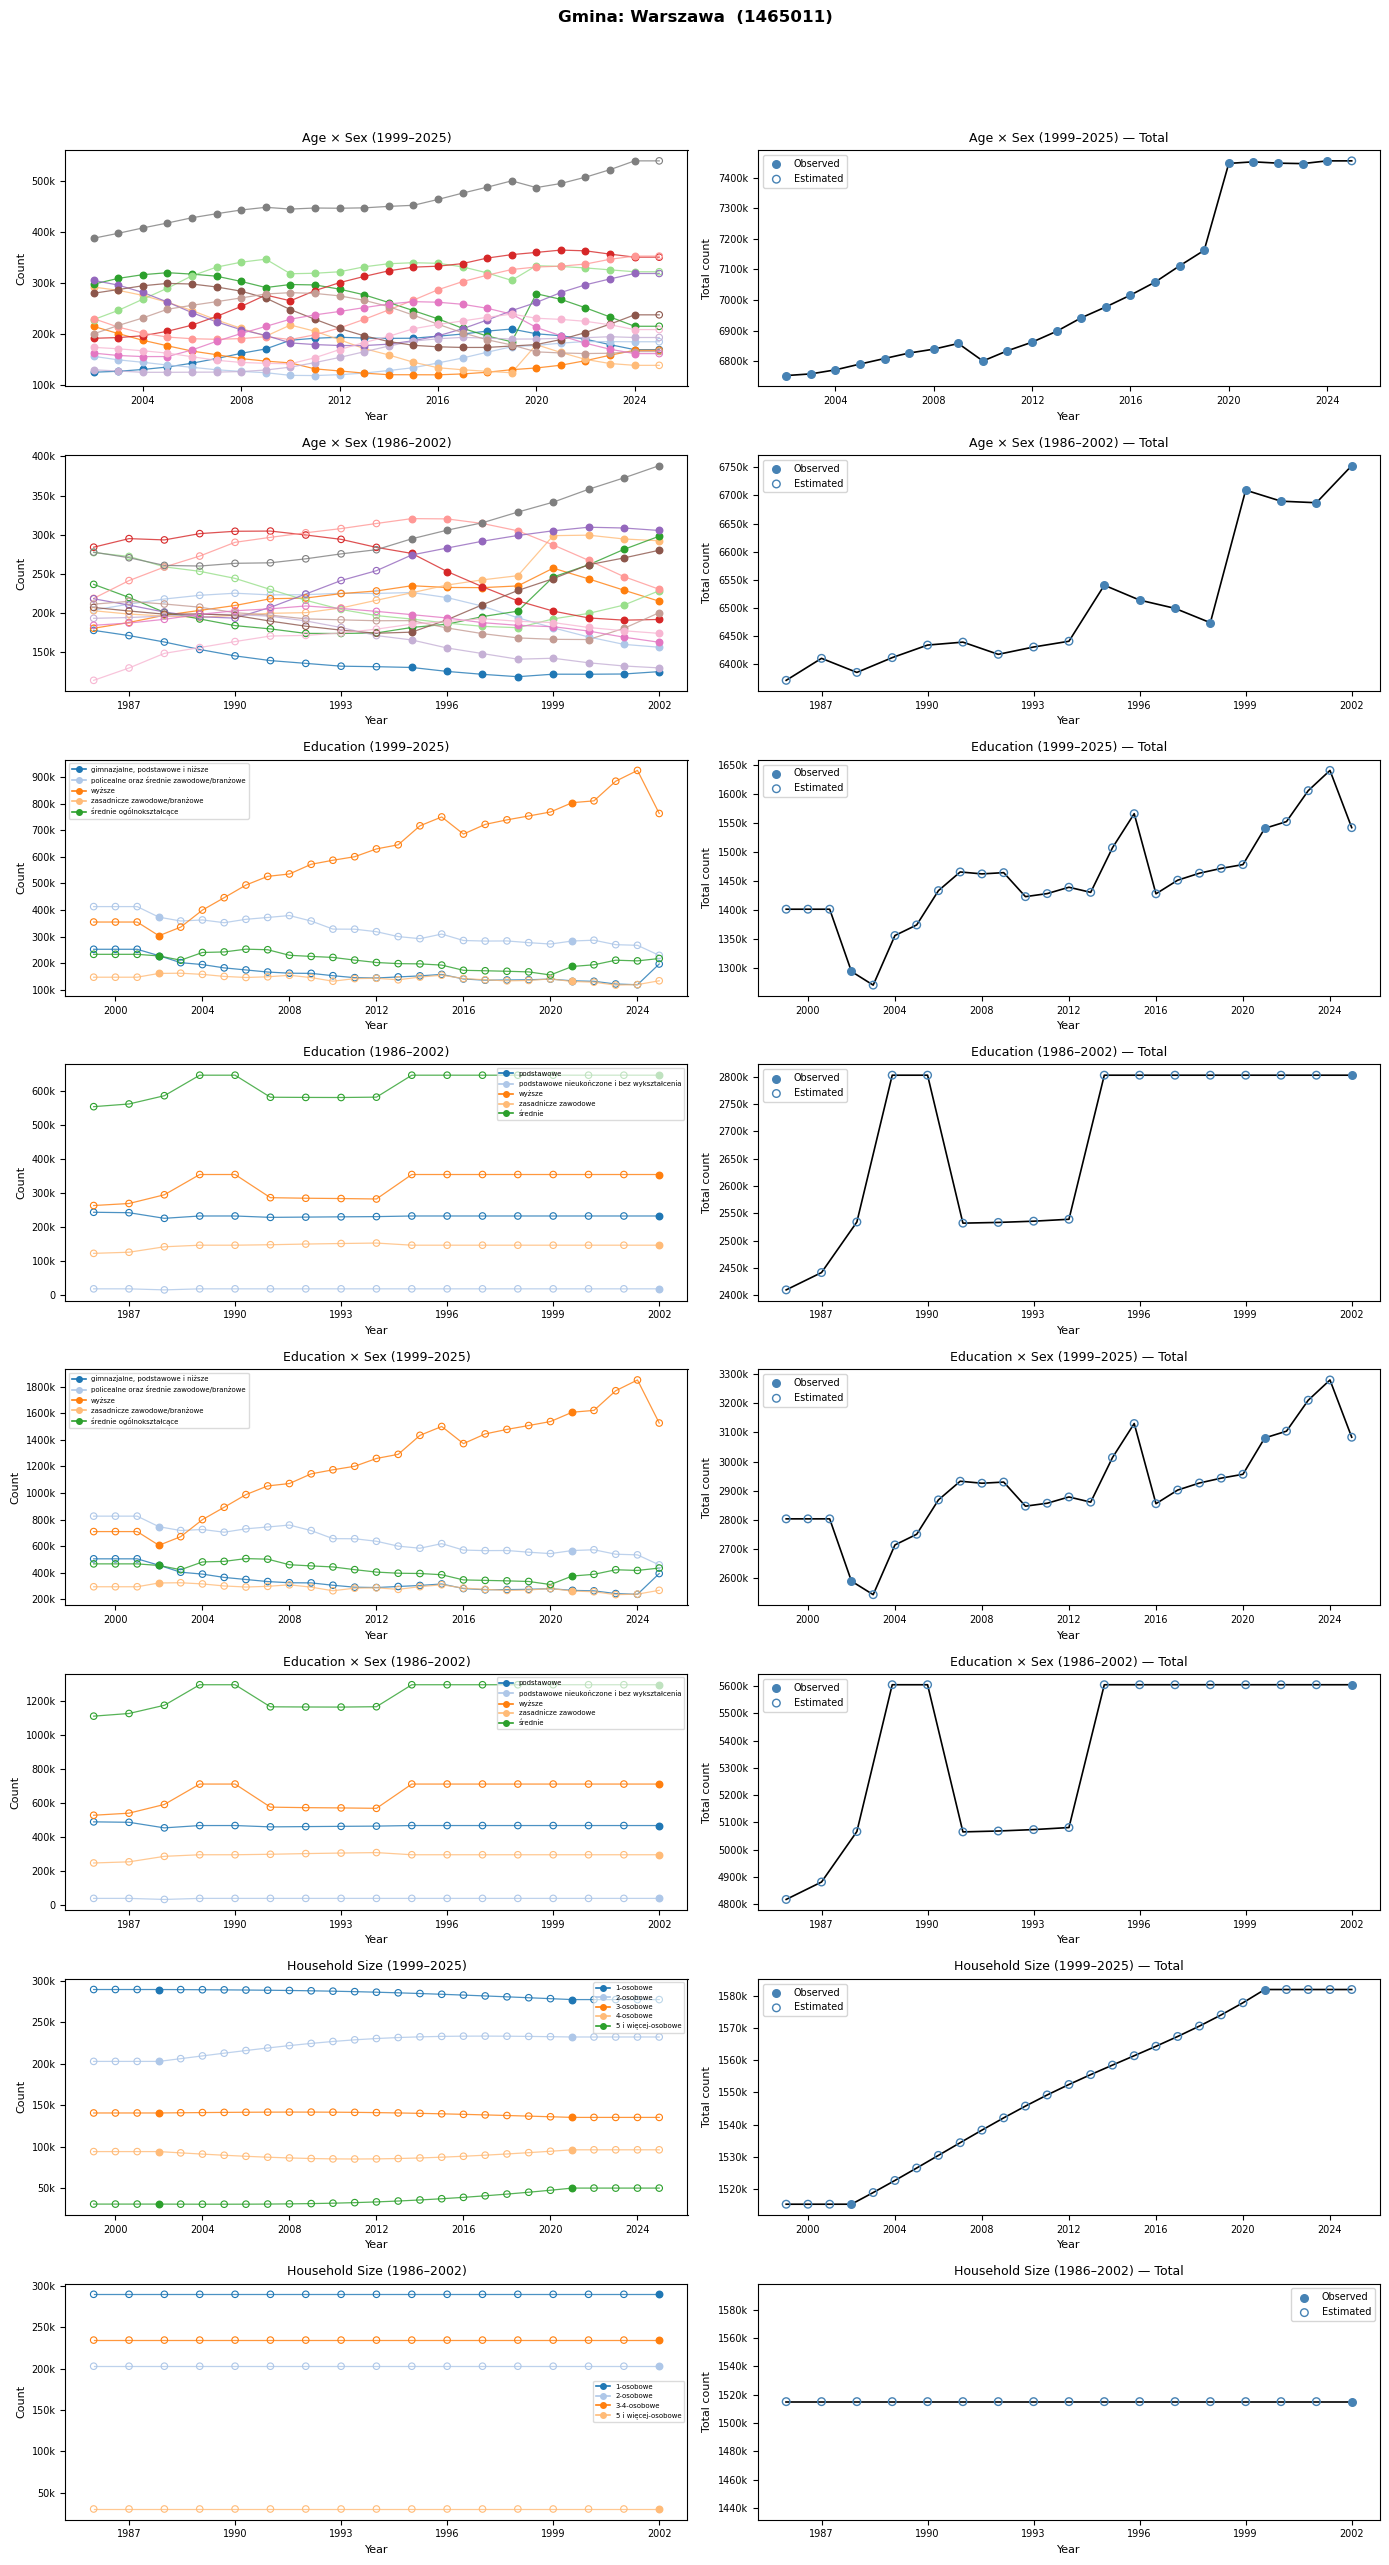

In [45]:
# ── Cell 8: Plot — sampled gmina ──────────────────────────────────────
sampled_gmina = db.get_by_teryt_id('1465011')
plot_all_subjects(
    sampled_gmina,
    f'Gmina: {sampled_gmina.name}  ({sampled_gmina.teryt_id})',
    is_gmina=True,
)

## 2.  Random Powiat

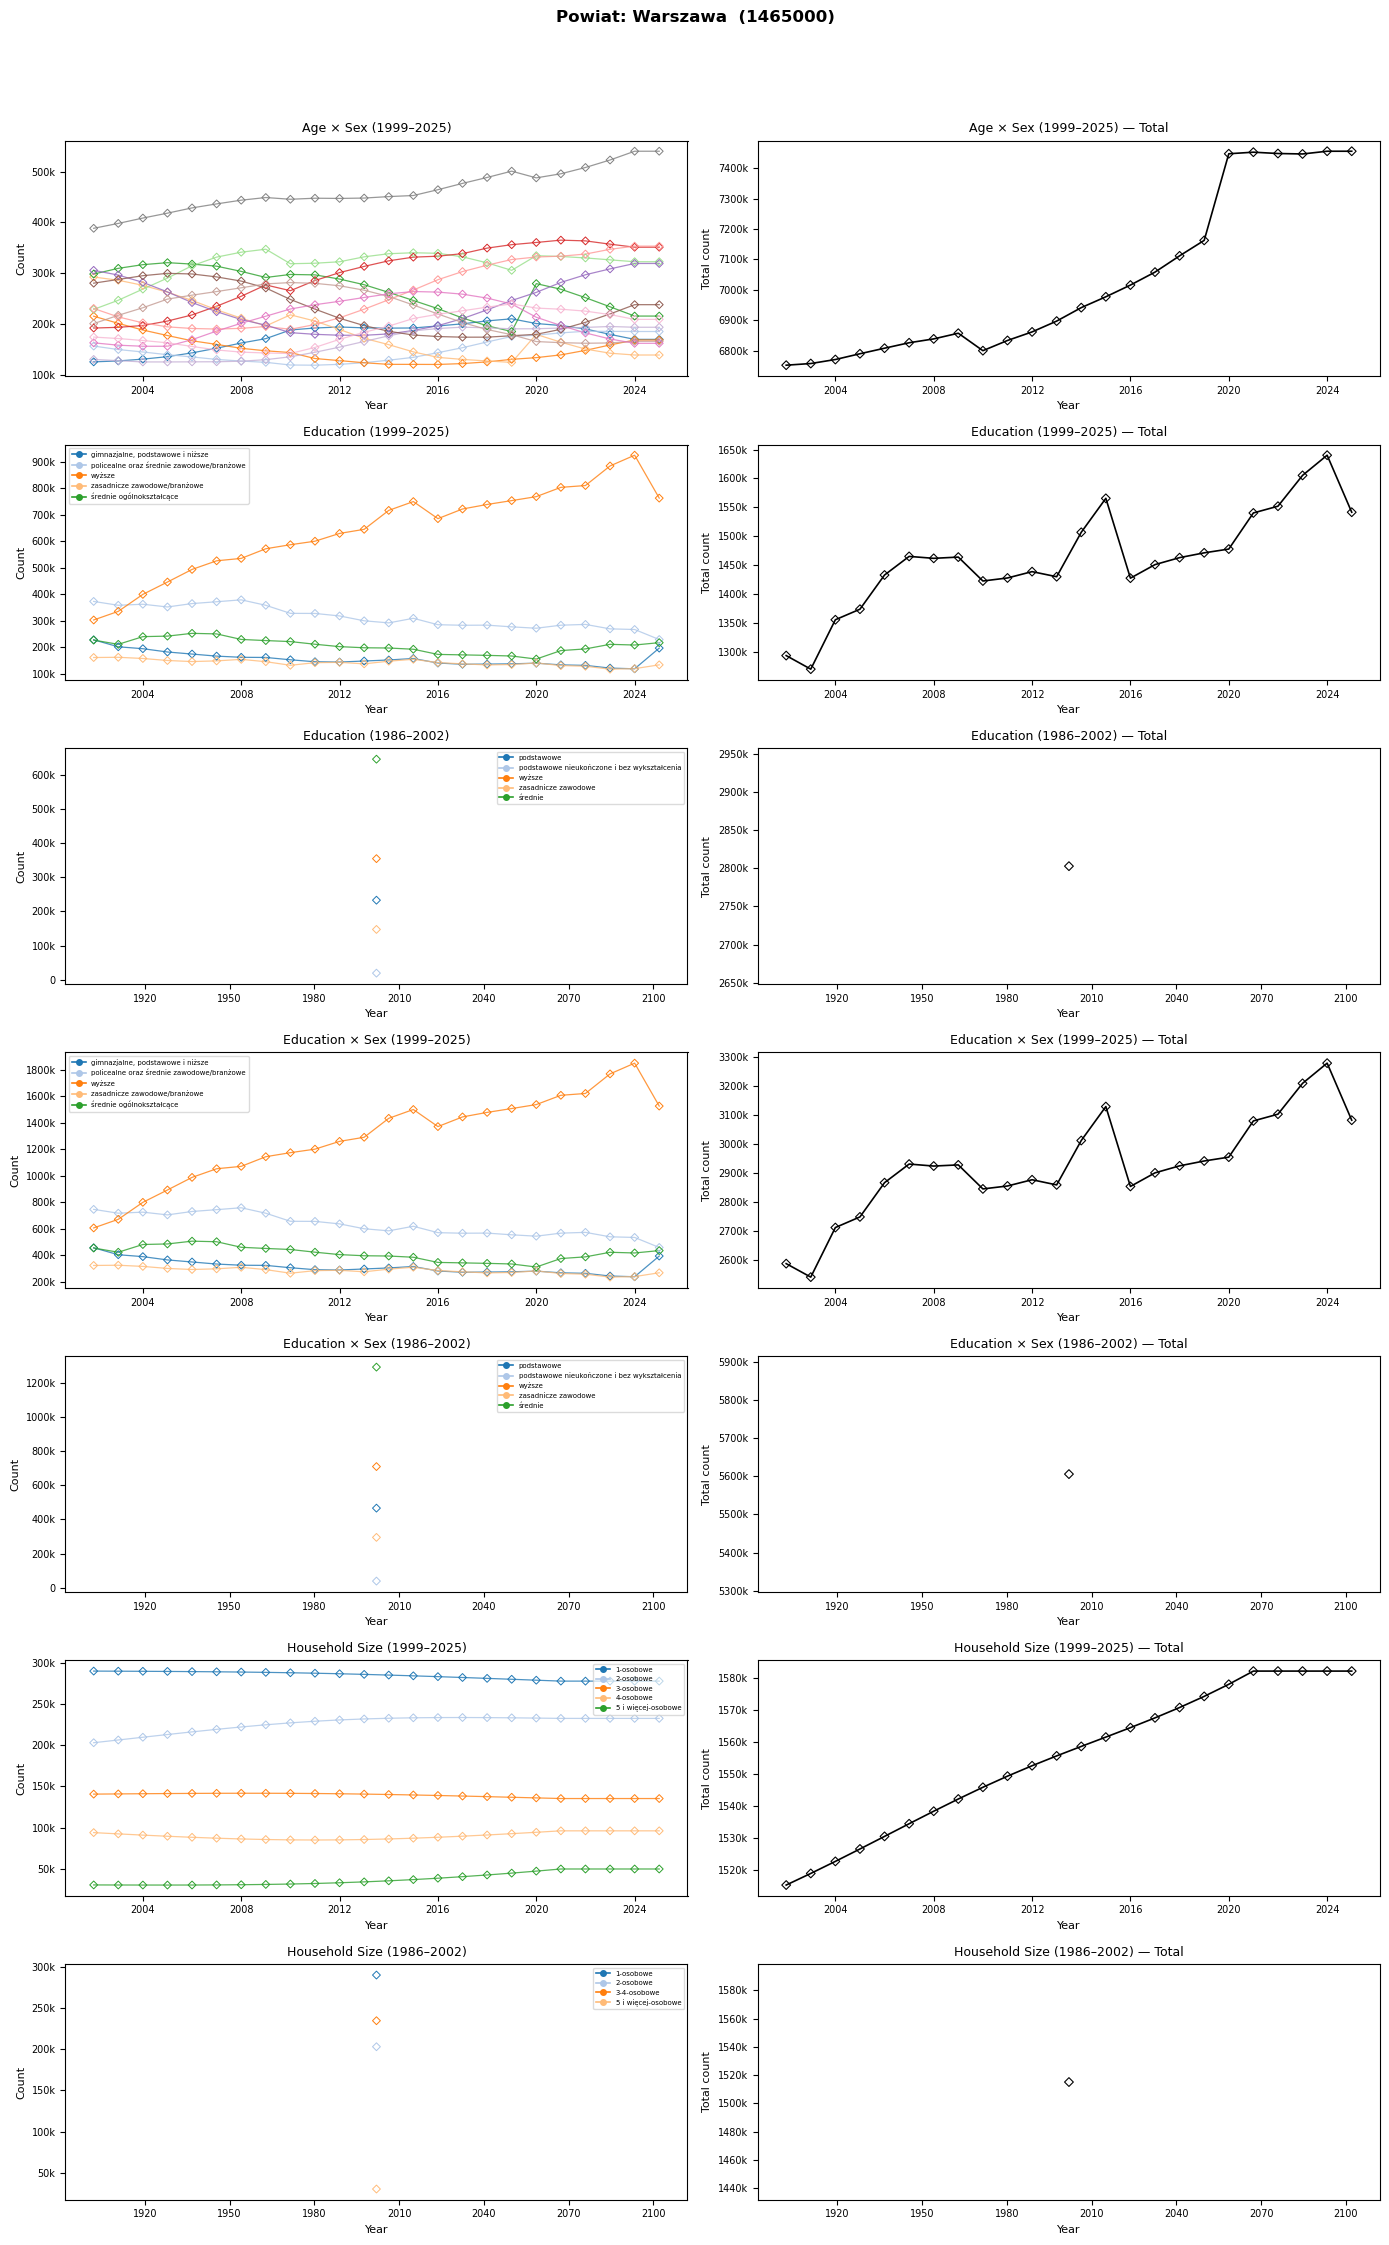

In [ ]:
# ── Cell 9: Plot — sampled powiat ─────────────────────────────────────
plot_all_subjects(
    sampled_powiat,
    f'Powiat: {sampled_powiat.name}  ({sampled_powiat.teryt_id})',
    is_gmina=False,
)

## 3.  Random New Voivodeship (post-1999)

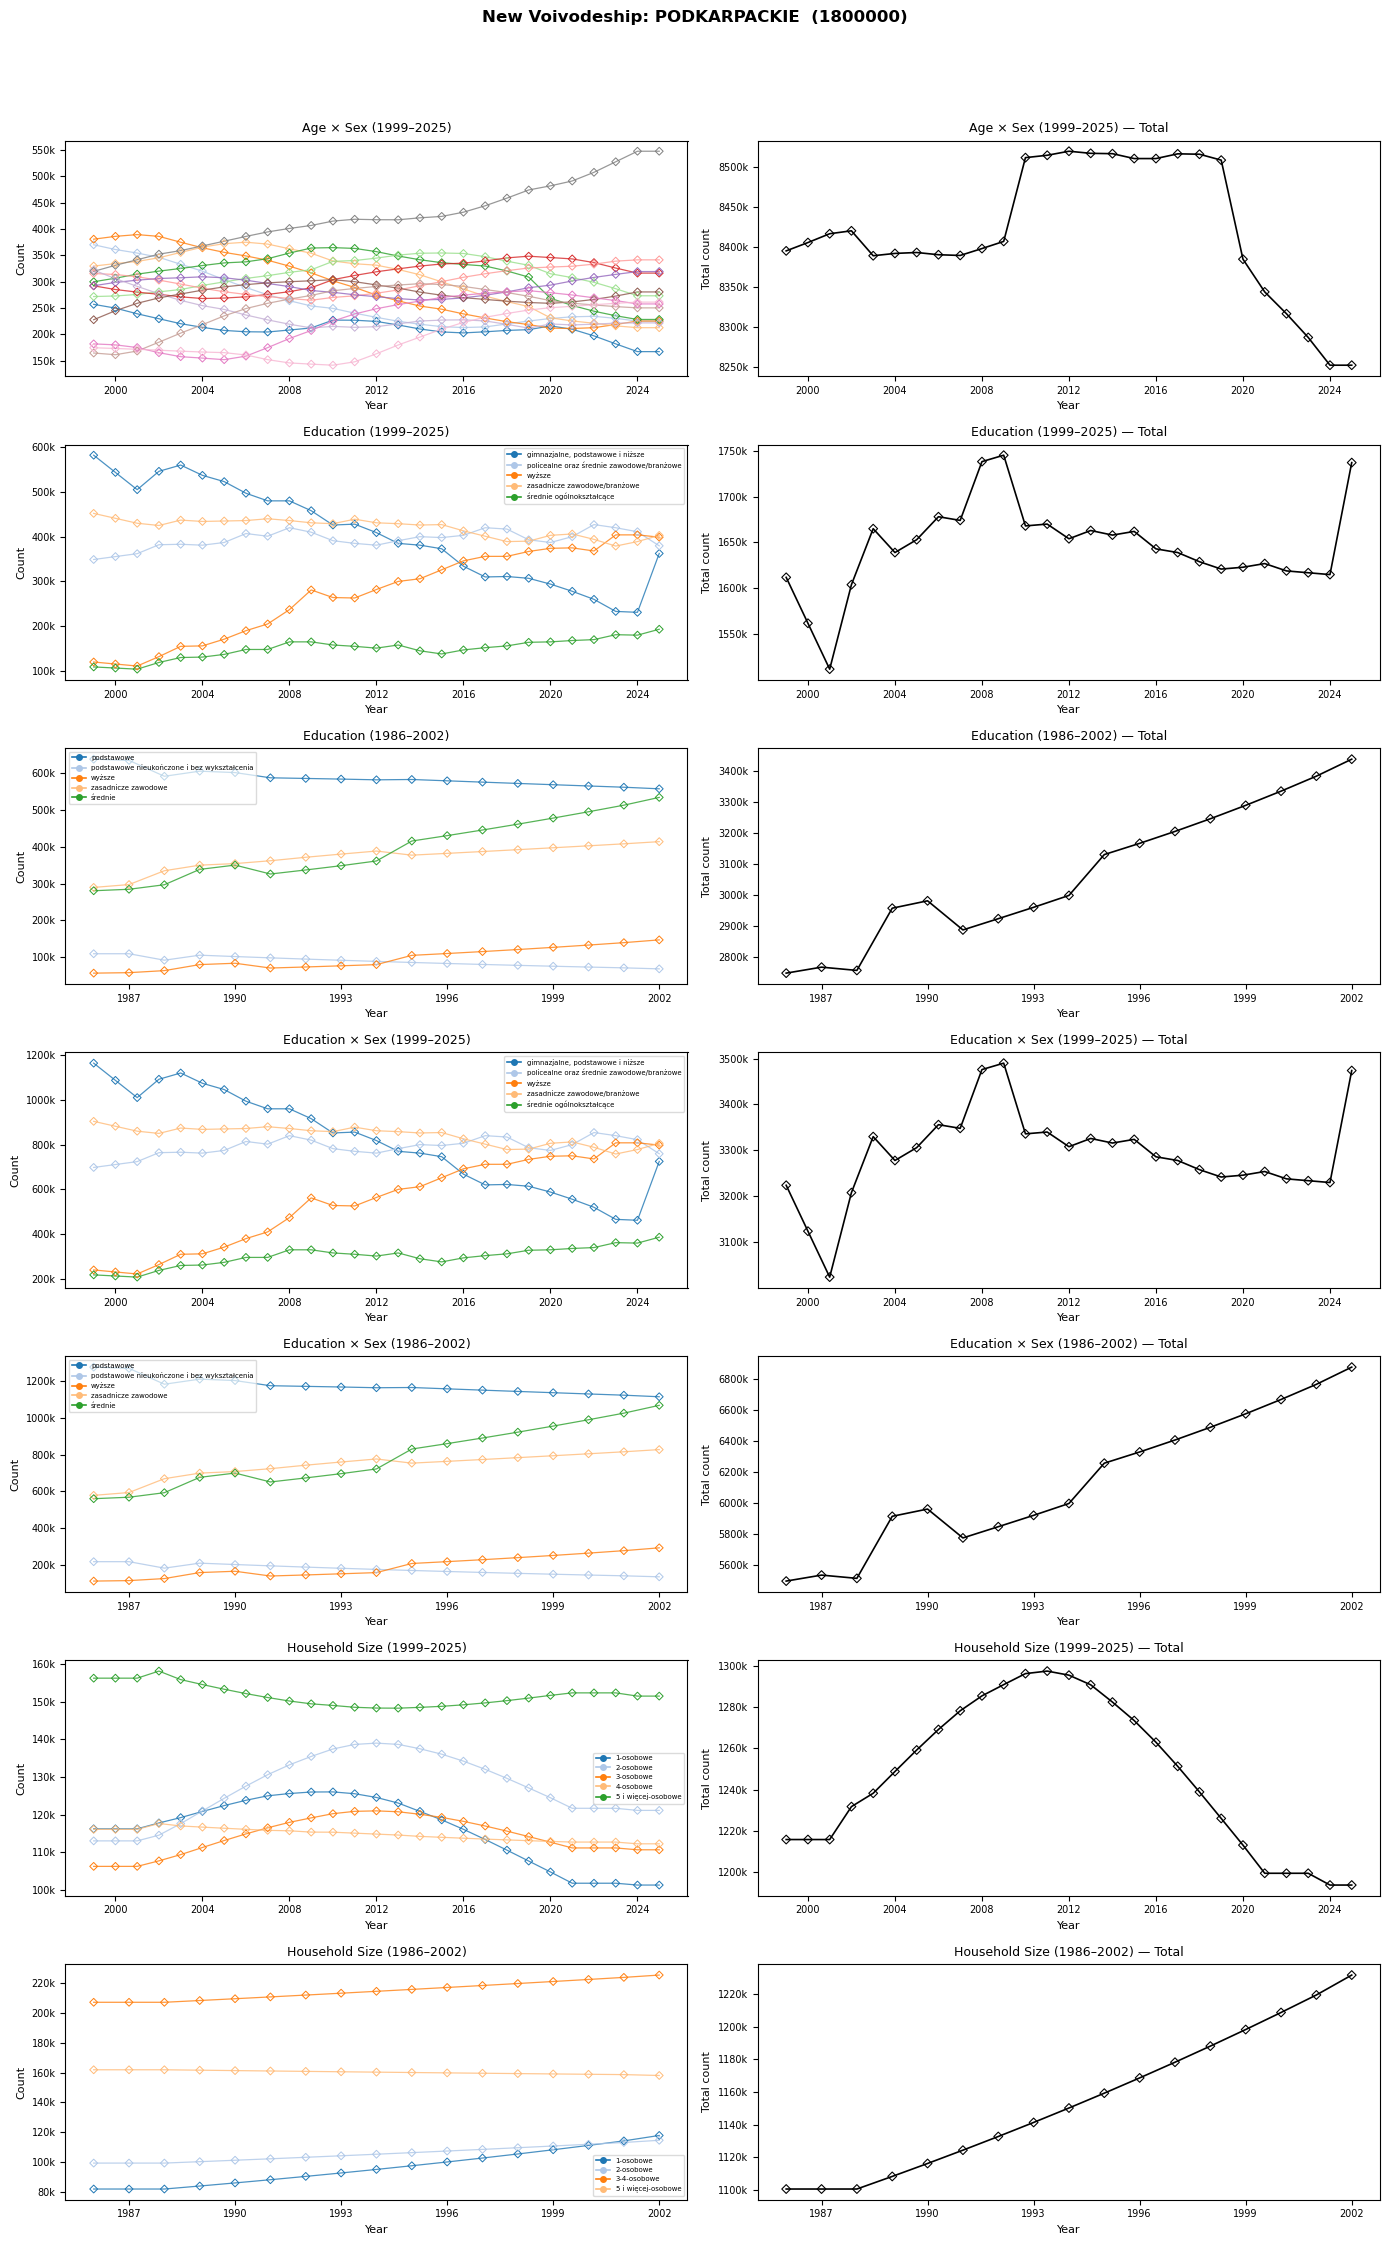

In [41]:
# ── Cell 10: Plot — sampled new voivodeship ───────────────────────────
plot_all_subjects(
    sampled_voiv,
    f'New Voivodeship: {sampled_voiv.name}  ({sampled_voiv.teryt_id})',
    is_gmina=False,
)

## 4.  Random Old Voivodeship (pre-1999)

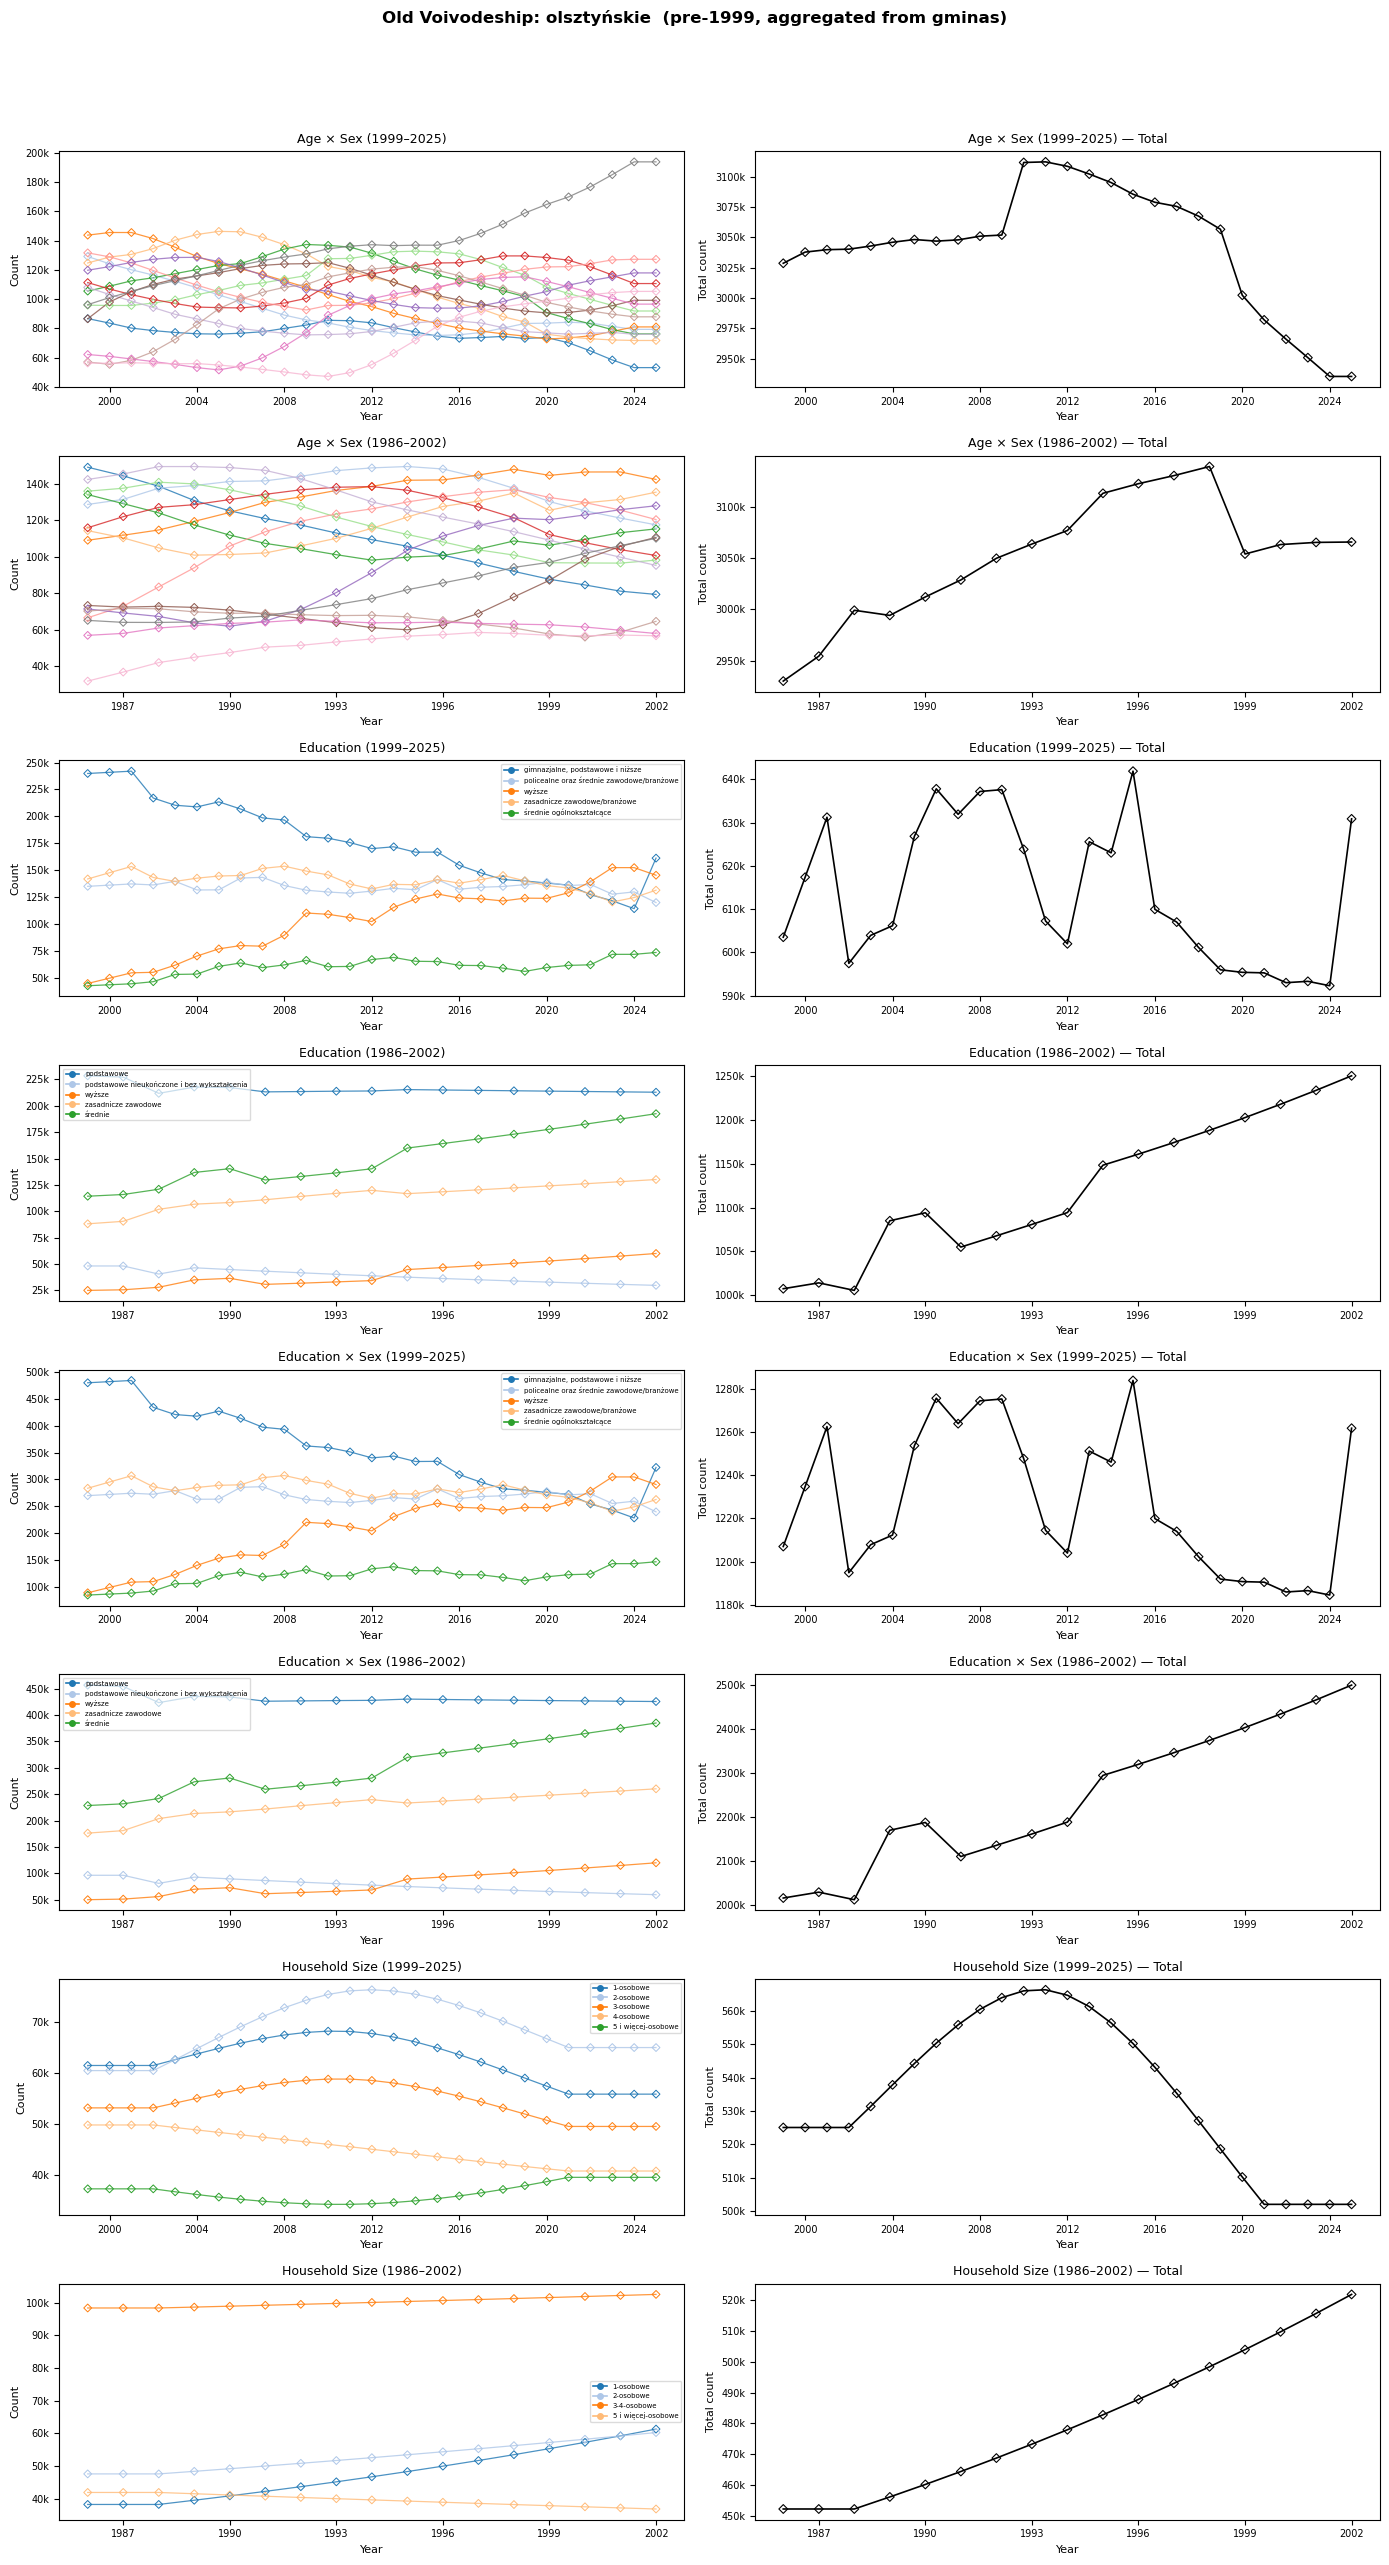

In [42]:
# ── Cell 11: Plot — sampled old voivodeship ───────────────────────────
plot_all_subjects(
    sampled_old_voiv_record,
    f'Old Voivodeship: {sampled_old_woj}  (pre-1999, aggregated from gminas)',
    is_gmina=False,
)

## 5.  Coverage Summary Table

In [43]:
# ── Cell 12: Summary — subject coverage across all territories ────────
#
# For each of the four sampled territories, show which E_ subjects
# are available, how many years have data, and (for the gmina) which
# years are observed vs estimated.

rows = []
territory_records = [
    ('Gmina', sampled_gmina),
    ('Powiat', sampled_powiat),
    ('New Voivodeship', sampled_voiv),
    ('Old Voivodeship', sampled_old_voiv_record),
]

for terr_label, rec in territory_records:
    for sid in e_sids:
        ct = rec.cross_tables.get(sid)
        if ct is None:
            rows.append({
                'Territory': terr_label,
                'Name': rec.name,
                'Subject': sid,
                'Years w/ data': 0,
                'Observed years': '-',
                'Estimated years': '-',
            })
            continue
        yrs = ct.years_with_data
        n_yrs = len(yrs)
        if terr_label == 'Gmina':
            obs_years = [y for y in yrs if is_year_observed(rec, sid, y)]
            est_years = [y for y in yrs if not is_year_observed(rec, sid, y)]
            rows.append({
                'Territory': terr_label,
                'Name': rec.name,
                'Subject': sid,
                'Years w/ data': n_yrs,
                'Observed years': len(obs_years),
                'Estimated years': len(est_years),
            })
        else:
            rows.append({
                'Territory': terr_label,
                'Name': rec.name,
                'Subject': sid,
                'Years w/ data': n_yrs,
                'Observed years': '(agg)',
                'Estimated years': n_yrs,
            })

summary_df = pd.DataFrame(rows)
display(summary_df)

,Territory,Name,Subject,Years w/ data,Observed years,Estimated years
0,Gmina,Płośnica,E_age_sex_2000,27,26,1
1,Gmina,Płośnica,E_age_sex_1990,17,9,8
2,Gmina,Płośnica,E_educ_2000,27,2,25
3,Gmina,Płośnica,E_educ_1990,17,2,15
4,Gmina,Płośnica,E_educ_sex_2000,27,2,25
5,Gmina,Płośnica,E_educ_sex_1990,17,1,16
6,Gmina,Płośnica,E_hh_size_2000,27,2,25
7,Gmina,Płośnica,E_hh_size_1990,17,2,15
8,Powiat,Leszno,E_age_sex_2000,27,(agg),27
9,Powiat,Leszno,E_age_sex_1990,0,-,-


## 6.  Detailed Gmina Drill-Down

Show the **raw cross-table DataFrames** for the sampled gmina —
one table per E\_ subject for the census years where observed data exists,
plus one estimated year for comparison.

In [44]:
# ── Cell 13: Drill-down — raw cross tables for sampled gmina ──────────

CENSUS_YEARS = [1988, 2002, 2011, 2021]

for sid in e_sids:
    ct = sampled_gmina.cross_tables.get(sid)
    if ct is None:
        continue
    data_years = ct.years_with_data
    if not data_years:
        continue

    print(f'\n{"=" * 60}')
    print(f'  {sid}  —  dims: {ct.dim_names}  shape: {ct.shape}')
    print(f'  Years with data: {data_years}')
    print(f'{"=" * 60}')

    # Show census years that have data + one estimated year
    show_years = [y for y in CENSUS_YEARS if y in data_years]
    # Pick a non-census year that has data
    estimated_years = [y for y in data_years if y not in CENSUS_YEARS]
    if estimated_years:
        mid = estimated_years[len(estimated_years) // 2]
        show_years.append(mid)

    for y in sorted(show_years):
        obs = is_year_observed(sampled_gmina, sid, y)
        tag = '● OBSERVED' if obs else '○ ESTIMATED'
        print(f'\n  Year {y} — {tag}')
        df_table = ct.get_as_dataframe(y)
        display(df_table)


  E_age_sex_2000  —  dims: ['n1', 'n2']  shape: (16, 3)
  Years with data: [1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

  Year 2002 — ● OBSERVED


,kobiety,mężczyźni,ogółem
0-4,186.0,176.0,362.0
10-14,239.0,267.0,506.0
15-19,317.0,286.0,603.0
20-24,176.0,217.0,393.0
25-29,196.0,222.0,418.0
30-34,177.0,213.0,390.0
35-39,201.0,180.0,381.0
40-44,185.0,215.0,400.0
45-49,182.0,235.0,417.0
5-9,214.0,241.0,455.0



  Year 2011 — ● OBSERVED


,kobiety,mężczyźni,ogółem
0-4,168.0,178.0,346.0
10-14,193.0,191.0,384.0
15-19,223.0,250.0,473.0
20-24,214.0,241.0,455.0
25-29,213.0,239.0,452.0
30-34,179.0,196.0,375.0
35-39,188.0,218.0,406.0
40-44,179.0,193.0,372.0
45-49,217.0,205.0,422.0
5-9,168.0,153.0,321.0



  Year 2013 — ● OBSERVED


...

,value
1-osobowe,237.0
2-osobowe,377.0
3-4-osobowe,710.0
5 i więcej-osobowe,485.0
ogółem,1809.0



  Year 1994 — ○ ESTIMATED


,value
1-osobowe,287.514873
2-osobowe,394.861466
3-4-osobowe,696.544648
5 i więcej-osobowe,455.528522
ogółem,1834.449508



  Year 2002 — ● OBSERVED


,value
1-osobowe,372.0
2-osobowe,420.0
3-4-osobowe,679.0
5 i więcej-osobowe,419.0
ogółem,1890.0


---

### Notes

- Re-run **Cell 4** (random sampling) to inspect a different set of
  territories.  Remove the `random.seed(SEED)` line for truly random
  draws each time.
- The *old voivodeship* plots may show small discrepancies from the
  new voivodeship totals, because the pre-1999 administrative borders
  do not align with post-1999 voivodeship boundaries.
- Observed/estimated markers on gmina plots derive from whether the
  **source M\_ anchor** has real census data at that (territory, year)
  pair.  They are not persisted in the database pickle and are
  reconstructed on the fly.